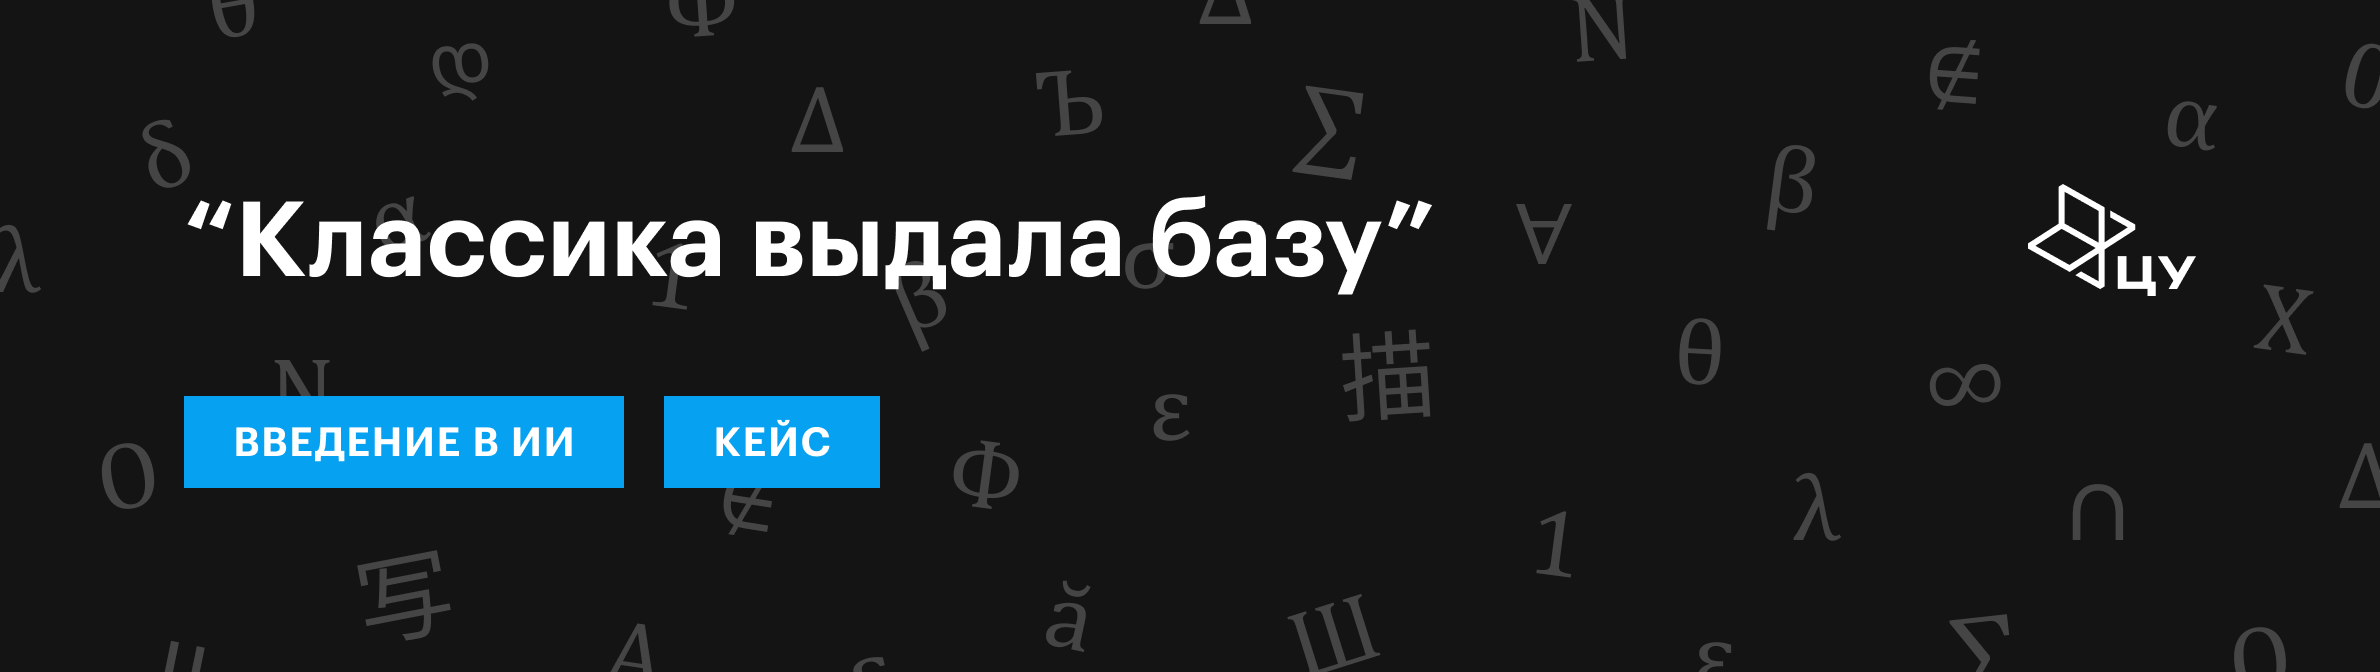

## Легенда

Представьте, что вы устроились NLP-инженером в образовательный EdTech-стартап. Маркетологи компании выяснили, что современные школьники тяжело воспринимают язык классической литературы XIX века.(Также в компанию наняли инженера, который смог встроить в каждую электронную книжкуу по экрану с Subway Surfers, чтобы ученикам было привычнее) Обилие устаревших слов, французских вставок и сложных деепричастных оборотов заставляет их «скипать» чтение.

Стартап решил запустить революционное приложение, которое будет «на лету» переводить тексты Толстого, Достоевского и Гоголя на современный интернет-сленг*.

Ваша задача: разработать нейросетевую Seq2Seq-модель, которая осуществляет перенос стиля (Text Style Transfer). Модель должна брать оригинальную реплику из классики и переписывать ее зумерским сленгом, максимально сохраняя смысл и изначальную структуру предложения.

*Примечение от автора кейса: данные по сленгу собирались из открытых источников: статей в интернете, рилсам, шортсам и тикитокам.*

## Требования к решению

Поскольку это учебный проект, вводятся следующие технические ограничения:

* **Запрет на API-читерство:** Запрещено просто прогнать тестовый датасет через API умных ЛЛМок. Вы должны самостоятельно обучить модель. *При этом, если вам хочется использовать API LLM-сервисов для обогащения датасета, аугментаций и уточнения перевода, то это не запрещено.*

* **Ограничение по размеру модели:** Решение должно корректно работать в Google Colab. Использовать несколько Google-аккаунтов для увеличения квоты на Т4 для экспериментов с архитектурой не запрещено

* **Воспроизводимость:** Весь код должен выполняться последовательно с первого раза. Обязательно фиксируйте random_seed, а также сохраняйте веса моделей и логируйте эксперимент.

**Необходимые этапы решения:**

1. Работа с датасетом. Посмотреть на статистику встречаемости слов и провести предобработку. Определиться с токенизатором и предложить простой бейзлайн.


2. Подбор архитектуры модели. Написание необходимых функций для работы с данной архитектурой. (Например, обрезка текста до 128 символов, для моделей с маленьким контекстным окном)


3. Обучение модели на датасете. Валидация метрик, подбор гиперпарметров генерации. Вспомогательные функции для генерации перевода для новых предложений (тут можно сделать функцию `def translate(text)`, которая занимается переводом текста)

**Проверяемые метрики:**

Оценка качества генерации текста — сложная задача. Мы будем использовать две метрики и смотреть на Loss модели:

*  Обучение (Train/Val Loss): Cross-Entropy Loss. Функция потерь, по которой модель обновляет веса. Желательно избежать переобучения и достичь результатов по Loss меньше ~1.5-2.0

* Главная бизнес-метрика: chrF (Character n-gram F-score). Оценивает совпадение сгенерированного текста с эталоном на уровне символов. Она идеально подходит для сленга, так как прощает ошибки в окончаниях (например, если модель выдала «кринж» вместо «кринжово»).

*  Вспомогательная метрика: BLEU-score. Классическая метрика машинного перевода. Посчитайте её для сравнения с chrF. Данная метрика легко считается и является бейзлайн-метрикой для любой задачи перевода.





## Система оценивания

Решение оценивается по трём параметрам
* **Работа с данными [4 балла]:** Оценка ставится в соответствии с тем, насколько подробно была произведена работа с данными — визуализации, предобработка и очистка/обогащение датасета будут плюсом

* **Решение задачи [4 балла]:** Оценка ставится не за итоговые метрики — для простых моделей их значение может быть небольшим, а за то, насколько качественно были проделаны эксперименты в рамках выбранной модели. То есть если в решении используется примитивная модель, получающая низкие метрики, но она обучена с разными гиперпараметрами и приёмами так, что из её качества выжимается максимум, это решение будет оценено в полный балл

* **Оформление [2 балла]:** Хочется, чтобы написанный код читался, как хорошая книга. Для этого мы добавляем баллы за оформление — они выше, если в коде появляются визуализации, комментарии к коду и сопроводительный текст, и ниже за их отсутствие

## Данные

Итоговый датасет содержит 2 колонки: chunk и translate. В столбце chunk находится кусочек текста из классики. А в столбце translate – соответствующий ему перевод.


В данном датасете вы можете найти отрывки из следующих книг / сборников / произведений:

* А. П. Чехов — Собрание сочинений (рассказы и пьесы)

* А. С. Пушкин — повесть «Пиковая дама»

* И. С. Тургенев — роман «Отцы и дети»

* М. Ю. Лермонтов — роман «Герой нашего времени»

* Н. В. Гоголь — комедия «Ревизор»

* Н. В. Гоголь — поэма «Мёртвые души»

* А. Н. Островский — Собрание пьес (включая драму «Гроза»)

* Л. Н. Толстой — роман-эпопея «Война и мир»

* Ф. М. Достоевский — роман «Братья Карамазовы»



Для подбора метода, желательно подробно исследовать датасет – можно начать с простого просмотра перевода, а закончить построение векторных представлений слов. *Главное помните, EDA должен привести вас к пониманию решения проблемы*

Ссылка на датасет: https://drive.google.com/file/d/1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7/view

## Пояснение метрик



**BLEU-score** (Bilingual Evaluation Understudy)
Метрика основана на совпадении целых слов (униграмм) и их комбинаций (n-грамм: биграмм, триграмм и т.д.). Итоговый BLEU считается как геометрическое среднее точностей n-грамм, умноженное на штраф за краткость.

Формула:
$BLEU = BP \cdot \exp\left( \sum_{n=1}^{N} w_n \log p_n \right)$

Где:

$p_n$ — точность совпадения n-грамм (доля n-грамм из генерации, которые нашлись в эталоне).

$w_n$ — вес для $n$-граммы (обычно берут равномерные веса, например, для BLEU-4: $w_n = 0.25$).

$N$ — максимальная длина n-граммы (стандарт — 4).

$BP$ (Brevity Penalty) — штраф за краткость. Запрещает модели читерить, выдавая по одному правильному слову.

Формула штрафа за краткость ($BP$):
BP = \begin{cases} 1, & \text{если } c > r \\ \exp\left(1 - \frac{r}{c}\right), & \text{если } c \le r \end{cases}
Где $c$ — длина сгенерированного текста (candidate), $r$ — длина эталона (reference).



**chrF** (Character n-gram F-score)
В отличие от BLEU, chrF разбивает текст не на слова, а на символьные подстроки (от 1 до 6 символов) и считает по ним классическую F-меру.

Сначала считаются Precision и Recall для совпавших символьных кусочков:

$Precision (P) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в генерации}}$


$Recall (R) = \frac{\text{Кол-во совпавших символьных n-грамм}}{\text{Общее кол-во символьных n-грамм в эталоне}}$

Затем вычисляется итоговая формула chrF (это стандартная $F_\beta$-мера):

$chrF = (1 + \beta^2) \frac{P \cdot R}{\beta^2 \cdot P + R}$

Где:

$\beta$ — параметр, определяющий баланс между точностью и полнотой.

В стандартной реализации (chrF2) используют $\beta = 2$, что дает больший вес Recall (полноте) — то есть алгоритму важнее, чтобы модель не потеряла смысл оригинала, даже если она добавила от себя лишние символы.

### Пример работы метрик

**Оригинал:** "Это было ужасно"

**Эталон**: "это было кринжово"

**Сгенерировано моделью:** "это был кринж"

----



BLEU разбивает текст по пробелам:

Слова эталона: ["это", "было", "кринжово"]

Слова модели: ["это", "был", "кринж"]

Для BLEU слова "было" и "был", а также "кринжово" и "кринж" — это абсолютно разные, никак не связанные слова (как "собака" и "самолет"). Совпало только одно слово: "это".


Шаг 1: Считаем совпадения (Precision для n-грамм)

1-граммы (отдельные слова): Из 3 сгенерированных слов в эталоне есть только одно — "это". $p_1 = 1 / 3 \approx 0.33$ (33%).

2-граммы (пары слов):
Пары модели: ["это был", "был кринж"].
Пары эталона: ["это было", "было кринжово"].
Совпадений нет! Точность $p_2 = 0 / 2 = 0$.

Шаг 2: Штраф за краткость (Brevity Penalty)
Длина генерации ($c=3$) равна длине эталона ($r=3$), поэтому модель не штрафуется за обрывание текста. $BP = 1$

Шаг 3: Итоговая формула BLEU

$$BLEU = BP \cdot \exp\left( \frac{1}{2} \log p_1 + \frac{1}{2} \log p_2 \right)$$

Так как точность биграмм $p_2 = 0$, логарифм нуля уходит в минус бесконечность, и весь BLEU обнуляется.

$$BLEU = 0$$

- - -

chrF нарезает текст на куски (например, по 4 символа, включая пробелы):

Куски эталона (14 штук):
"это_", "то_б", "о_бы", "_был", "было", "ыло_", "ло_к", "о_кр", "_кри", "крин", "ринж", "инжо", "нжов", "жово"

Куски модели (10 штук):
"это_", "то_б", "о_бы", "_был", "был_", "ыл_к", "л_кр", "_кри", "крин", "ринж"

Шаг 1: Ищем совпадения
Алгоритм сравнивает два списка и находит 7 идеальных совпадений:
"это_", "то_б", "о_бы", "_был", "_кри", "крин", "ринж". Корень слова и начало предложения схвачены верно!

Алгоритм видит, что куски "это ", "то б", " был", " кри", "крин", "ринж" совпали


Шаг 2: Считаем Точность (Precision) и Полноту (Recall)

Precision ($P$): Доля правильных кусков среди всех сгенерированных.
$P = 7 / 10 = 0.70$ (70% того, что выдала модель — верно).

Recall ($R$): Доля кусков эталона, которые смогла покрыть модель.
$R = 7 / 14 = 0.50$ (Модель восстановила 50% от оригинальной строки).

Шаг 3: Итоговая формула (F2-score)
chrF по умолчанию использует $\beta = 2$, что дает Полноте в 2 раза больший вес, чем Точности (важнее не потерять смысл, чем не наделать опечаток).

$$chrF = 5 \frac{P \cdot R}{4p+R}$$

Подставляем наши числа и получаем ответ:

$$chrF = 5 \frac{0.7 \cdot 0.5}{4\cdot 0.7 + 0.5} \approx 0.53$$

### Код метрик

Ниже уже реализованы функции подсчёта метрик. Тебе необходимо лишь использовать их

In [ ]:
def get_word_ngrams(tokens: list, n: int) -> list:
    """
    Разбивает список токенов на n-граммы уровня слов.
    """
    return [tuple(tokens[i : i + n]) for i in range(len(tokens) - n + 1)]


def get_char_ngrams(text: str, n: int) -> list:
    """
    Разбивает строку на n-граммы уровня символов.
    """
    return [text[i : i + n] for i in range(len(text) - n + 1)]


Покажем как работает базовое разбиение на n-граммы: посимвольные и по-"подсловные".

In [ ]:
get_word_ngrams(["я", "тебя", "крашу", "чееел"], 2)

[('я', 'тебя'), ('тебя', 'крашу'), ('крашу', 'чееел')]

In [ ]:
get_char_ngrams("кринж", 3)

['кри', 'рин', 'инж']

Вычислим теперь наши метрики для двух наших текстов

In [ ]:
import math
from collections import Counter


def bleu_single(reference: str, candidate: str, max_n: int = 4) -> float:
    """
    Вычисляет BLEU-score для одной пары (reference, candidate).
    Шаги:
      1. Токенизация — разбиение по пробелам
      2. Clipped precision — для каждого n считаем долю n-грамм генерации,
         которые есть в эталоне; одна n-грамма эталона не засчитывается дважды
      3. Add-1 сглаживание — (matches + 1) / (total + 1), чтобы избежать log(0)
         при нулевых совпадениях в высших n-граммах
      4. Brevity Penalty — штраф exp(1 - r/c), если генерация короче эталона

    Args:
        reference : эталонный текст (строка)
        candidate : сгенерированный текст (строка)
        max_n     : максимальный порядок n-граммы (по умолчанию 4 → BLEU-4)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    ref_tokens  = reference.lower().split()
    cand_tokens = candidate.lower().split()

    c = len(cand_tokens)
    r = len(ref_tokens)

    if c == 0:
        return 0.0

    # Штрафуем только за генерацию короче эталона; длиннее — штрафа нет
    bp  = 1.0 if c > r else math.exp(1 - r / c)
    w_n = 1.0 / max_n
    log_avg = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_word_ngrams(ref_tokens, n))
        cand_ngrams = Counter(get_word_ngrams(cand_tokens, n))

        # Clipped: не даём модели накручивать счёт повторами одной n-граммы
        matches = sum(min(cnt, ref_ngrams[ngram]) for ngram, cnt in cand_ngrams.items())
        total   = max(c - n + 1, 1)  # floor=1, если предложение короче n

        # Нет совпадений даже на уровне слов — тексты семантически разные
        if n == 1 and matches == 0:
            return 0.0

        p_n      = (matches + 1) / (total + 1)
        log_avg += w_n * math.log(p_n)

    return bp * math.exp(log_avg)


def chrf_single(reference: str, candidate: str, max_n: int = 6, beta: float = 2.0) -> float:
    """
    Вычисляет chrF-score для одной пары (reference, candidate).

    Шаги:
      1. Разбить оба текста на символьные n-граммы (для n от 1 до max_n)
      2. Для каждого n посчитать Precision и Recall по совпавшим кускам
      3. Усреднить Precision и Recall по всем n
      4. Итог: F_beta-мера из усредненных P и R

    Args:
        reference  : эталонный текст (строка)
        candidate  : сгенерированный текст (строка)
        max_n      : максимальный порядок символьной n-граммы (по умолчанию 6)
        beta       : вес Recall относительно Precision (по умолчанию 2.0 -> chrF2)

    Returns:
        float в диапазоне [0.0, 1.0]
    """
    if len(candidate) == 0 or len(reference) == 0:
        return 0.0

    total_precision = 0.0
    total_recall    = 0.0

    for n in range(1, max_n + 1):
        ref_ngrams  = Counter(get_char_ngrams(reference, n))
        cand_ngrams = Counter(get_char_ngrams(candidate, n))

        # Считаем совпавшие символьные куски
        matches = sum(
            min(count, ref_ngrams.get(ngram, 0))
            for ngram, count in cand_ngrams.items()
        )

        total_cand = sum(cand_ngrams.values())  # знаменатель Precision
        total_ref  = sum(ref_ngrams.values())   # знаменатель Recall

        if total_cand > 0:
            total_precision += (matches + 1)/ (total_cand + 1)
        if total_ref > 0:
            total_recall += matches / total_ref

    # Усредняем Precision и Recall по всем порядкам n
    avg_p = total_precision / max_n
    avg_r = total_recall    / max_n

    if avg_p + avg_r == 0:
        return 0.0

    # считаем f-бета меру
    chrf = (1 + beta**2) * (avg_p * avg_r) / (beta**2 * avg_p + avg_r)
    return chrf

А теперь с помощью функций выше напишем вычисление метрик для массива текстов. Мы используем такой же интерфейс как у `sci-kit-learn`, где есть необходимо передать `y_true` и `y_pred`

In [ ]:
def compute_bleu(y_true: list, y_pred: list, max_n: int = 4) -> float:
    """Считает средний BLEU по всем парам датасета."""
    scores = [bleu_single(ref, cand, max_n) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


def compute_chrf(y_true: list, y_pred: list, max_n: int = 6, beta: float = 2.0) -> float:
    """Считает средний chrF по всем парам датасета."""
    scores = [chrf_single(ref, cand, max_n, beta) for ref, cand in zip(y_true, y_pred)]
    return sum(scores) / len(scores)


### **0 Импорт библиотек**

In [ ]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, TrainingArguments, Trainer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq

from sklearn.manifold import TSNE

from datasets import Dataset

from tqdm.auto import tqdm

import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

In [ ]:
import gdown
gdown.download(id="1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7")

Downloading...
From: https://drive.google.com/uc?id=1wn6jpF5-FeaZIo2oqSspSvbfjIiVa8F7
To: /Users/a1pha/ai_intro/cases/NLP case/data/dataset.csv
100%|██████████| 31.9M/31.9M [00:02<00:00, 11.9MB/s]


'data/dataset.csv'

In [ ]:
raw_df = pd.read_csv("data/dataset.csv")

In [ ]:
raw_df.head(5)

,chunk,translate
0,Михаил Лермонтов\n\nГерой нашего времени\n\nВо...,в любом лонгриде предисловие — это база и одно...
1,Эта книга испытала на себе еще недавно несчаст...,этот лонгрид жестко забайтил некоторых читател...
2,"Вы скажете, что нравственность от этого не выи...","скажете, что от такого контента у общества пад..."
3,Уж солнце начинало прятаться за снеговой хребе...,солнце уже ливало за снежные пики когда я вкат...
4,За моею тележкою четверка быков тащила другую ...,за моей тачкой четверка быков на изи тащила др...


In [ ]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3624 entries, 0 to 3623
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   chunk      3624 non-null   str  
 1   translate  3613 non-null   str  
dtypes: str(2)
memory usage: 30.5 MB


In [ ]:
raw_df = raw_df.dropna()

Итак, мы имеем датасет на $\approx 3600$ записей. Рассмотрим дальнейшие действия по очистке и преобразованию датасета:
1. Приведение к нижнему регистру
2. Удаление всех non-славянских символов
3. Удаление стоп-слов
4. Лемматизация (только для классических текстов)
5. Повторная фильтрация стоп-слов
6. Токенизация

Касательно выбранной модели и, соответственно, токенизатора. Мы будем использовать "форк" большой гугловской модели `t5-base`, которая отлично решает задачи перевода style-to-style (сам придумал, однако правда решает хорошо). Данная версия отличается лишь тем, что содержит лишь часть, отвечающую за работу со славянскими языками (т.е. токены, веса и пр.)

In [ ]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^а-яё.,!?;:ё\-\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
raw_df["chunk"] = raw_df["chunk"].map(preprocess)
raw_df["translate"] = raw_df["translate"].map(preprocess)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-base")
raw_dataset = Dataset.from_pandas(raw_df)

def tokenize(batch):
    inputs = tokenizer(batch["chunk"], truncation=True, max_length=128)
    targets = tokenizer(batch["translate"], truncation=True, max_length=128)
    inputs["labels"] = targets["input_ids"]
    return inputs

Разделяем датасет на тренировочную и валидационную части (используем встроенные в датасет из HF метод).

In [ ]:
dataset = raw_dataset.map(tokenize, batched=True, remove_columns=raw_dataset.column_names)
dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)
train_val_dict = dataset.train_test_split(test_size=0.15, seed=42)

train_dataset = train_val_dict["train"]
val_dataset = train_val_dict["test"]

Map:   0%|          | 0/3613 [00:00<?, ? examples/s]

In [ ]:
texts = raw_df["chunk"].tolist()
translations = raw_df["translate"].tolist()

input_lengths = [len(t.split()) for t in texts]
target_lengths = [len(t.split()) for t in translations]

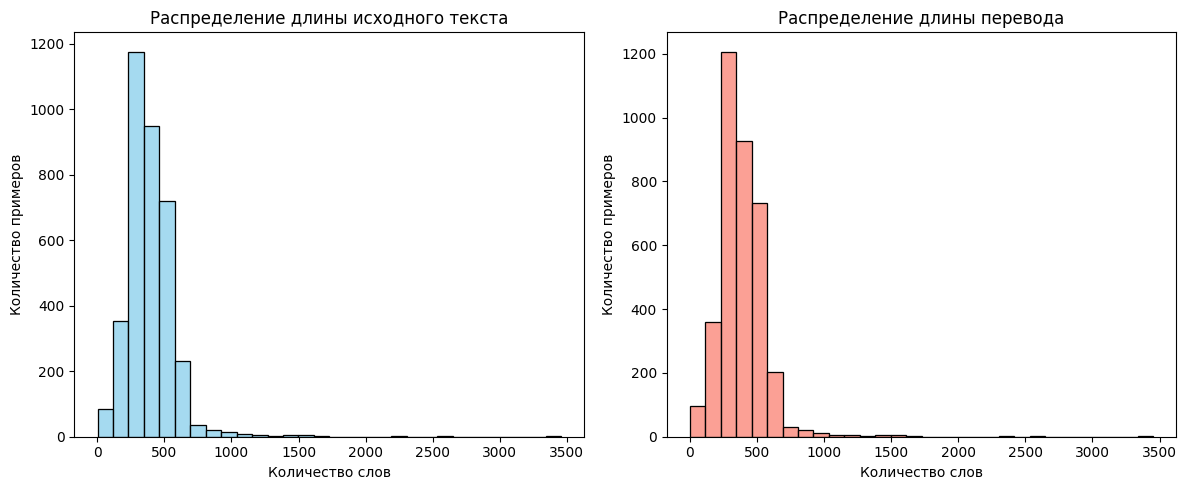

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(input_lengths, bins=30, color="skyblue", ax=ax1)
ax1.set_title("Распределение длины исходного текста")
ax1.set_xlabel("Количество слов")
ax1.set_ylabel("Количество примеров")

sns.histplot(target_lengths, bins=30, color="salmon", ax=ax2)
ax2.set_title("Распределение длины перевода")
ax2.set_xlabel("Количество слов")
ax2.set_ylabel("Количество примеров")

plt.tight_layout()
plt.show()

In [ ]:
all_input_ids = [item['input_ids'] for item in dataset] + [item["labels"] for item in dataset]
all_labels = ["chunk"] * len(dataset) + ["translate"] * len(dataset)

all_input_ids = pad_sequence(all_input_ids, batch_first=True, padding_value=0).float()
tsne = TSNE(n_components=2, random_state=42)
emb_2d = tsne.fit_transform(all_input_ids.numpy())

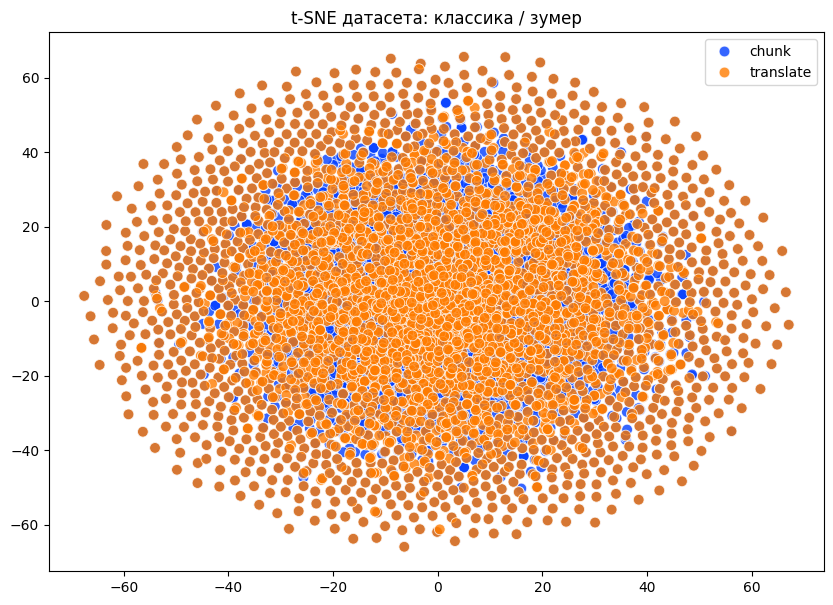

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=emb_2d[:,0],
    y=emb_2d[:,1],
    hue=all_labels,
    palette="bright",
    s=60,
    alpha=0.8
)
plt.title("t-SNE датасета: классика / зумер")
plt.show()

Из визуализации можно понять следующее:
1. Смена "языка" не повлияла на длины предложений.
2. Как видно из t-SNE, перевод имеет более "обширный" диапазон, засчет новых токенов, однако "ядро" остается тем же.

Теперь небольшое пояснение к ужасу ниже:
1. `model` - сама модель с HF
2. `data_collator` - полезная утилита, которая помогает настроить обработку батчами плюс выполняет за нас некоторые манипуляции с токенизацией (паддинги + обработотка токенов паддинга - замена на $-100$)
3. `training_args` - аргументы, которые можно всяческим образом крутить для улучшения производительности и качества, по порядку:
    - `output_dir` - директория для сохранения артефактов обучения
    - `per_device_train_batch_size` - более актуально для счастливых владельцев SLI/CrossFire, однако для Colab'а тоже стоит указать
    - `per_device_eval_batch_size` - то же самое
    - `gradient_accumulation_steps` - задает количество просчитываемых шагов градиента для батча
    - `num_train_epochs` - число эпох
    - `learning_rate` - о, ужас, это правда LR
    - `logging_steps` - период логирования
    - `save_steps` - период сохранения артефактов
    - `save_total_limit` - максимальное кол-во сохраняемых артефактов
    - `dataloader_pin_memory` - интерпретатор ругался
    - `fp16` - вычисления быстрее, качество на том же уровне
    - `seed` - очев
4. `trainer` - вспомогательный класс HF для быстрого fine-tuning
5. `trainer.train()` - запуск процесса обучения

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-base")

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
)

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=8,
    learning_rate=3e-5,
    logging_steps=100,
    save_steps=500,
    save_total_limit=2,
    dataloader_pin_memory=False,
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

trainer.train()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Step,Training Loss
100,86.950801
200,32.816780
300,12.885916
400,11.498583
500,10.469460
600,9.774482
700,9.289933
800,9.461589
900,9.087936
1000,8.475391


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3072, training_loss=11.884757300217947, metrics={'train_runtime': 13229.2116, 'train_samples_per_second': 1.857, 'train_steps_per_second': 0.232, 'total_flos': 4156208000040960.0, 'train_loss': 11.884757300217947, 'epoch': 8.0})

Ниже - функция для генерации ответа (а-ля `model.predict`)

In [ ]:
def generate_zoomer_batch(texts, max_length=64):
    model.eval()

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=max_length,
            do_sample=True,
            top_k=50,
            top_p=0.8,
            repetition_penalty=2.0,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    decoded_outputs = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    return decoded_outputs

In [ ]:
print(*generate_zoomer_batch(
    ["""
    Мороз и солнце, день чудесный!
    Еще ты дремлешь, друг прелестный
    """]
))

на вайбе и солнце, день чудесный! Еще ты дремлешь, друг прелестный. Может, ты всю


## Итог



In [ ]:
def validate(dataset, model, tokenizer):
    model.eval()

    total_loss = 0
    predictions = []
    references = []

    for batch in tqdm(dataset):
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        labels = batch["labels"].to(model.device)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            total_loss += outputs.loss.item()

        texts = tokenizer.batch_decode(input_ids, skip_special_tokens=True)

        batch_predictions = generate_zoomer_batch(texts)
        predictions.extend(batch_predictions)

        labels_for_decode = labels.clone()
        labels_for_decode[labels_for_decode == -100] = tokenizer.pad_token_id
        batch_references = tokenizer.batch_decode(labels_for_decode, skip_special_tokens=True)
        references.extend(batch_references)

    return total_loss / len(dataset), references, predictions

In [ ]:
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

dataloader = DataLoader(dataset, batch_size=32, collate_fn=data_collator)

loss, predictions, references = validate(dataloader, model, tokenizer)

chr_f = compute_chrf(predictions, references)
bleu = compute_bleu(predictions, references)

  0%|          | 0/113 [00:00<?, ?it/s]

In [ ]:
def translate(old_text):
    return generate_zoomer_batch([old_text])[0]

In [ ]:
example = \
'''
Я вас любил: любовь еще, быть может,
В душе моей угасла не совсем
'''

translated_example = translate(example)

print(f"Кросс-энтропия: {loss}\nChr-F: {chr_f}\nBLEU: {bleu}\n\nПеревод: {translated_example}")

Кросс-энтропия: 0.8114174189029542
Chr-F: 0.46403676052759224
BLEU: 0.24629455260031305

Перевод: такой вайб на мой жесткий тильт! Я вас любил: любовь еще, быть может, в душе моей угасла не совсем. в душ моей зашкварила и не сейчас поняла: любовью еще


[Музыка из кухни]

Знаете, на самом деле не так важны полученные метрики, как опыт, который мы получили при работе с этим кейсом: NLP, HuggingFace, embeddings, transformers.

Ну а если серьезно, то спустя счетное число попыток, не удалось добиться результата лучше, тому есть две причины:
1. Выбранная модель не подходит для данной задачи, возмонжо, стоило попробовать оригинальную `t5-base`
2. Результат на примере выше в целом похож на тот, что должен был быть, так что как сырое решение, которое достаточно подкрутить (например посмотреть на гиперпараметры в функции генерации)